1. Dataset Preparation
2. EDA

3. ANN + TF-IDF

4. 1D CNN
   ├── Basic CNN
   └── Kernel/filter experiments

5. RNNs
   ├── Simple RNN
   ├── GRU
   ├── LSTM
   ├── BiLSTM
   └── BiGRU
       └── N-gram experiments (5, 10, 100)

6. Pre-trained Embeddings
   ├── FastText
   ├── Word2Vec
   └── BERT

7. Transformer

8. LLM Evaluation
   ├── Zero-shot
   ├── One-shot
   └── Few-shot

9. Final Results Analysis
   ├── Model comparison
   ├── Embedding comparison
   ├── LLM comparison
   └── Visualizations

# 1. Dataset Prepration 

In [ ]:
# Data handling
import os
import re
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Text vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input,
    Dense,
    Dropout,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    SimpleRNN,
    GRU,
    LSTM,
    Bidirectional
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Display TensorFlow version
print("TensorFlow version:", tf.__version__)

In [4]:
DATA_PATH = "/kaggle/input/datasets/crawford/20-newsgroups"

# Get all newsgroup text files
files = [f for f in os.listdir(DATA_PATH) if f.endswith(".txt")]

print("Number of files:", len(files))
print(files)

Number of files: 20
['misc.forsale.txt', 'rec.autos.txt', 'comp.os.ms-windows.misc.txt', 'sci.electronics.txt', 'comp.sys.mac.hardware.txt', 'talk.politics.mideast.txt', 'talk.politics.guns.txt', 'talk.religion.misc.txt', 'comp.graphics.txt', 'soc.religion.christian.txt', 'rec.sport.hockey.txt', 'rec.sport.baseball.txt', 'comp.windows.x.txt', 'comp.sys.ibm.pc.hardware.txt', 'rec.motorcycles.txt', 'sci.med.txt', 'sci.space.txt', 'alt.atheism.txt', 'sci.crypt.txt', 'talk.politics.misc.txt']


In [5]:
# Load documents and labels\
documents = []
labels = []

for file in files:
    label = file.replace(".txt", "")
    
    with open(os.path.join(DATA_PATH, file), "r", encoding="latin1") as f:
        content = f.read()
    
    # Each message starts with "Newsgroup:"
    messages = re.split(r"(?=Newsgroup:)", content)
    
    for message in messages:
        message = message.strip()
        
        if message:
            documents.append(message)
            labels.append(label)

df = pd.DataFrame({
    "text": documents,
    "label": labels
})

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (37662, 2)


,text,label
0,Newsgroup: misc.forsale\ndocument_id: 70337\nF...,misc.forsale
1,Newsgroup: misc.forsale\ndocument_id: 74150\nF...,misc.forsale
2,Newsgroup: misc.forsale\ndocument_id: 74720\nF...,misc.forsale
3,Newsgroup: misc.forsale\ndocument_id: 74721\nF...,misc.forsale
4,Newsgroup: misc.forsale\ndocument_id: 74722\nF...,misc.forsale


In [6]:
# Beofre cleaning 

for i in range(5):
    print(f"\n{'='*20} DOCUMENT {i} {'='*20}")
    print(df["text"].iloc[i])


==================== DOCUMENT 0 ====================
Newsgroup: misc.forsale
document_id: 70337
From: kedz@bigwpi.WPI.EDU (John Kedziora)
Subject: Motorcycle wanted.

Sender: 
Followup-To:kedz@wpi.wpi.edu 
Distribution: ne
Organization: Worcester Polytechnic Institute
Keywords: 

I am looking for an inexpensive motorcycle, nothing fancy, have to be able to do all maintinence my self. looking in the <$400 range.

if you can help me out, GREAT!, please reply by e-mail.

==================== DOCUMENT 1 ====================
Newsgroup: misc.forsale
document_id: 74150
From: myoakam@cis.ohio-state.edu (micah r yoakam)
Subject: BOAT for SALE

BOAT For SALE
1989 23' IMPERIAL FISHERMAN featuring
        Walkaround Cuddy Cabin, 305 V8 with VOLVO DUO PROP OUTDRIVE /\/\/\/
AM-FM Cassette Stereo, VHF RADIO, 4x6 HUMMINGBIRD Fishfinder, ALL  Safty
equipment, Covers, and MUCH MORE.  
        18000 LB.  Capacity
        includes Storage Trailer
        Hardly used:  LESS Than 100 Hrs

Asking: $15,000 O

In [7]:
import re

def clean_text(text):

    # 1. Remove headers but keep Subject
    text = re.sub(
        r"^Newsgroup:.*?\n"
        r"document_id:.*?\n"
        r"From:.*?\n"
        r"Subject:\s*",
        "",
        text,
        flags=re.IGNORECASE | re.DOTALL
    )

    # 2. Remove remaining metadata headers
    text = re.sub(
        r"^(Sender:.*?\n|Followup-To:.*?\n|Distribution:.*?\n|Organization:.*?\n|Keywords:.*?\n)+",
        "",
        text,
        flags=re.IGNORECASE | re.MULTILINE
    )

    # 3. Remove quoted lines
    text = re.sub(r"(?m)^>.*$\n?", "", text)

    # 4. Remove signature
    text = re.split(r"(?m)^--\s*$", text)[0]

    # 5. Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)

    # 6. Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # 7. Remove phone numbers
    text = re.sub(r"\b(?:\+?\d[\d\s().-]{7,}\d)\b", " ", text)

    # 8. Remove numbers
    text = re.sub(r"\b\d+\b", " ", text)

    # 9. Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # 10. Convert to lowercase
    text = text.lower()

    # 11. Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [8]:
df["text"] = df["text"].apply(clean_text)

for i in range(5):
    print(f"\n{'='*20} CLEANED DOCUMENT {i} {'='*20}")
    print(df["text"].iloc[i])


==================== CLEANED DOCUMENT 0 ====================
motorcycle wanted i am looking for an inexpensive motorcycle nothing fancy have to be able to do all maintinence my self looking in the range if you can help me out great please reply by e mail

==================== CLEANED DOCUMENT 1 ====================
boat for sale boat for sale imperial fisherman featuring walkaround cuddy cabin v with volvo duo prop outdrive am fm cassette stereo vhf radio x hummingbird fishfinder all safty equipment covers and much more lb capacity includes storage trailer hardly used less than hrs asking or best offer for further information contact gerald at mansfield oh

==================== CLEANED DOCUMENT 2 ====================
wanted brother p touch as it says i m interested in buying one of the little label makers and i can t afford a new one anybody tired of theirs e mail maureen

==================== CLEANED DOCUMENT 3 ====================
make your own talking elevators complete standalone 

In [9]:
#Train / Validation / Test split
X = df["text"]
y = df["label"]

# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 26363
Validation: 5649
Test: 5650


# 2. EDA


In [10]:
# Count documents in each newsgroup
class_counts = df["label"].value_counts().sort_index()

print(class_counts)

label
alt.atheism                 1599
comp.graphics               1947
comp.os.ms-windows.misc     1970
comp.sys.ibm.pc.hardware    1964
comp.sys.mac.hardware       1922
comp.windows.x              1960
misc.forsale                1944
rec.autos                   1980
rec.motorcycles             1988
rec.sport.baseball          1988
rec.sport.hockey            1998
sci.crypt                   1982
sci.electronics             1966
sci.med                     1980
sci.space                   1974
soc.religion.christian      1994
talk.politics.guns          1820
talk.politics.mideast       1880
talk.politics.misc          1550
talk.religion.misc          1256
Name: count, dtype: int64


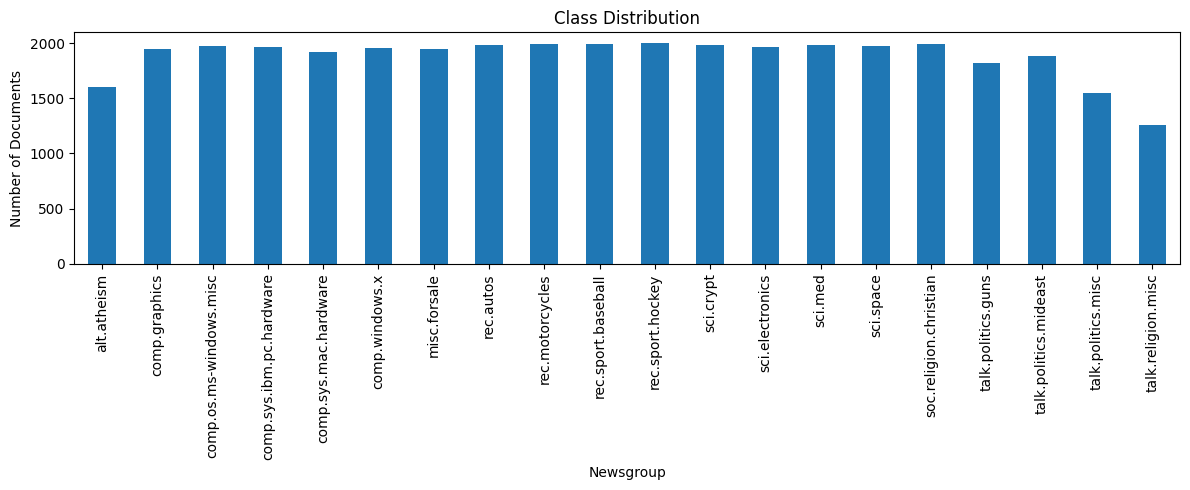

In [11]:
import matplotlib.pyplot as plt

# Plot number of documents per class
class_counts.plot(kind="bar", figsize=(12, 5))

plt.title("Class Distribution")
plt.xlabel("Newsgroup")
plt.ylabel("Number of Documents")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 3. Baseline Model — ANN + TF-IDF

## 3.1 Text into numerical TF-IDF features
Text
 ↓
TF-IDF
 ↓
10,000 numerical features
 ↓
ANN

In [13]:
#Create TF-IDF Features
# Convert text into TF-IDF features
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("Train shape:", X_train_tfidf.shape)
print("Validation shape:", X_val_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Train shape: (26363, 10000)
Validation shape: (5649, 10000)
Test shape: (5650, 10000)


In [14]:
#Encode the Labels
from sklearn.preprocessing import LabelEncoder

# Convert class names into numerical labels
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)

Classes: ['alt.atheism' 'comp.graphics' 'comp.os.ms-windows.misc'
 'comp.sys.ibm.pc.hardware' 'comp.sys.mac.hardware' 'comp.windows.x'
 'misc.forsale' 'rec.autos' 'rec.motorcycles' 'rec.sport.baseball'
 'rec.sport.hockey' 'sci.crypt' 'sci.electronics' 'sci.med' 'sci.space'
 'soc.religion.christian' 'talk.politics.guns' 'talk.politics.mideast'
 'talk.politics.misc' 'talk.religion.misc']


In [15]:
# Check final shapes before building the ANN
print("TF-IDF features:", X_train_tfidf.shape[1])
print("Number of classes:", len(label_encoder.classes_))
print("Training samples:", X_train_tfidf.shape[0])

TF-IDF features: 10000
Number of classes: 20
Training samples: 26363


## 3.2 ANN Input Preparation
Our TF-IDF matrices are sparse, while a basic ANN expects dense numerical input. Since we limited TF-IDF to 10,000 features, we can convert them to dense format.


In [16]:
# Convert TF-IDF matrices to dense arrays for the ANN
X_train_dense = X_train_tfidf.toarray()
X_val_dense = X_val_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()

print("Train shape:", X_train_dense.shape)
print("Validation shape:", X_val_dense.shape)
print("Test shape:", X_test_dense.shape)

Train shape: (26363, 10000)
Validation shape: (5649, 10000)
Test shape: (5650, 10000)


In [17]:
from tensorflow.keras.utils import to_categorical

# Convert class labels to one-hot format
num_classes = len(label_encoder.classes_)

y_train_cat = to_categorical(y_train_encoded, num_classes)
y_val_cat = to_categorical(y_val_encoded, num_classes)
y_test_cat = to_categorical(y_test_encoded, num_classes)

print("Label shape:", y_train_cat.shape)

Label shape: (26363, 20)


## 3.3 ANN Model

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Build a simple ANN for 20-class classification
model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_dense.shape[1],)),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1791241827.588104      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791241827.591515      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,282,708 (4.89 MB)

 Trainable params: 1,282,708 (4.89 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Configure the model for multi-class classification
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the ANN using the validation set for monitoring
history = model.fit(
    X_train_dense,
    y_train_cat,
    validation_data=(X_val_dense, y_val_cat),
    epochs=10,
    batch_size=32,
    verbose=1
)

# Evaluate the final model on unseen test data
test_loss, test_accuracy = model.evaluate(
    X_test_dense,
    y_test_cat,
    verbose=0
)

print("Test Accuracy:", round(test_accuracy, 4))

Epoch 1/10
 67/824 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1889 - loss: 2.9706

I0000 00:00:1791241912.042926     124 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


824/824 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7773 - loss: 1.2692 - val_accuracy: 0.9065 - val_loss: 0.4374
Epoch 2/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9432 - loss: 0.2669 - val_accuracy: 0.9465 - val_loss: 0.2388
Epoch 3/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9774 - loss: 0.1158 - val_accuracy: 0.9568 - val_loss: 0.1762
Epoch 4/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9896 - loss: 0.0594 - val_accuracy: 0.9600 - val_loss: 0.1484
Epoch 5/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9954 - loss: 0.0335 - val_accuracy: 0.9632 - val_loss: 0.1383
Epoch 6/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9968 - loss: 0.0214 - val_accuracy: 0.9632 - val_loss: 0.1404
Epoch 7/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9979 - loss: 0.0142 - val_accuracy: 0.9625 - val_loss: 0.1422
Epoch 8/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9983 - loss: 0.0107 - val_accuracy: 0.9639 - val_

## 3.4 ANN Evaluation

In [22]:
# Generate predictions for the test set
y_pred_probs = model.predict(X_test_dense)

# Convert probabilities to predicted class labels
y_pred = np.argmax(y_pred_probs, axis=1)

print("Predictions generated:", len(y_pred))

# Test text → ANN → 20 probabilities → highest probability → predicted class

177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predictions generated: 5650


In [27]:
# Test the classifier with new text
new_text = ["The hockey team did'nt won the game last night"]

# Convert text using the same TF-IDF vectorizer
new_text_tfidf = tfidf.transform(new_text)

# Convert to dense format
new_text_dense = new_text_tfidf.toarray()

# Predict the class
prediction_probs = model.predict(new_text_dense)
prediction = np.argmax(prediction_probs, axis=1)

print("Predicted newsgroup:", label_encoder.inverse_transform(prediction)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted newsgroup: rec.sport.hockey


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate classification metrics
accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred, average="weighted")
recall = recall_score(y_test_encoded, y_pred, average="weighted")
f1 = f1_score(y_test_encoded, y_pred, average="weighted")

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

Accuracy : 0.9637
Precision: 0.9642
Recall   : 0.9637
F1-score : 0.9638


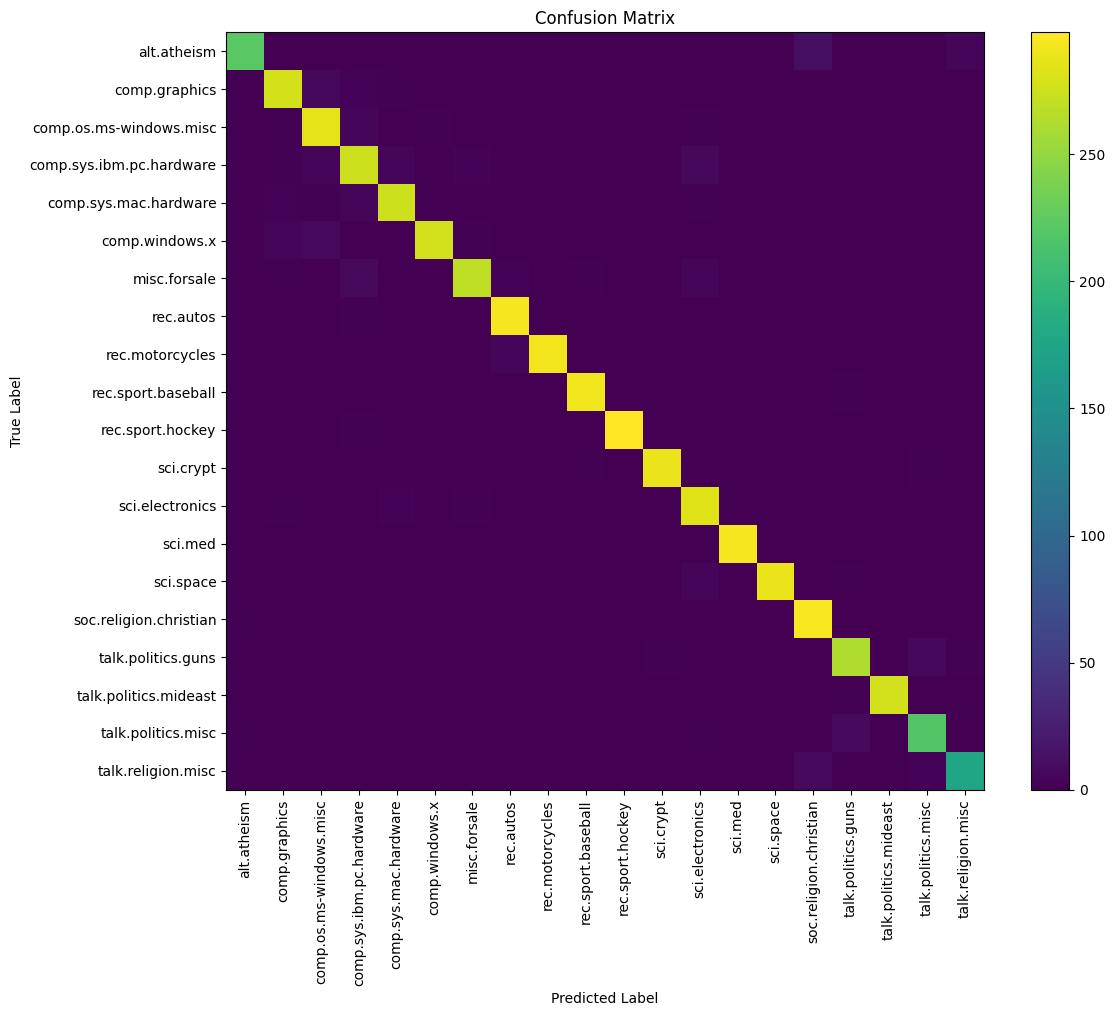

In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred)

# Display confusion matrix
plt.figure(figsize=(12, 10))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(
    range(num_classes),
    label_encoder.classes_,
    rotation=90
)
plt.yticks(
    range(num_classes),
    label_encoder.classes_
)

plt.tight_layout()
plt.show()

# 4. 1D CNN
Text → Tokenization → Sequences → Embedding → 1D CNN
Because CNN needs sequences of tokens to detect local patterns such as phrases, we won't use the TF-IDF vectors from the ANN.

We'll keep it simple and only do what the assignment asks:
Text Tokenization & Padding
Build 1D CNN
Experiment with kernel sizes / filters
Train using validation set
Evaluate
Accuracy
Precision
Recall
F1-score
Confusion matrix

## 4.1 Tokenization & Sequence Preparation

In [29]:
# Tokenize text into integer sequences
max_words = 10000

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

# Learn vocabulary only from training data
tokenizer.fit_on_texts(X_train)

# Convert text into integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("Training sequences:", len(X_train_seq))
print("Validation sequences:", len(X_val_seq))
print("Test sequences:", len(X_test_seq))

Training sequences: 26363
Validation sequences: 5649
Test sequences: 5650


In [30]:
# Check document sequence lengths
sequence_lengths = [len(seq) for seq in X_train_seq]

print("Minimum length:", min(sequence_lengths))
print("Maximum length:", max(sequence_lengths))
print("Average length:", np.mean(sequence_lengths))
print("Median length:", np.median(sequence_lengths))

Minimum length: 1
Maximum length: 20055
Average length: 207.90903918370444
Median length: 101.0


In [31]:
# Set a fixed sequence length
max_length = 300

# Pad sequences to the same length
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Training shape:", X_train_pad.shape)
print("Validation shape:", X_val_pad.shape)
print("Test shape:", X_test_pad.shape)

# 300 = maximum sequence length
# 10,000 = maximum vocabulary size

Training shape: (26363, 300)
Validation shape: (5649, 300)
Test shape: (5650, 300)


## 4.2 Build 1D CNN
Token IDs → Embedding → Conv1D → MaxPooling → Dense → Output

In [34]:
# Number of words in the vocabulary
vocab_size = min(max_words, len(tokenizer.word_index) + 1)

# Build the 1D CNN model
cnn_model = Sequential([
    Input(shape=(max_length,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),

    Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu"
    ),

    GlobalMaxPooling1D(),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(num_classes, activation="softmax")
])

cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 300, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 296, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,381,140 (5.27 MB)

 Trainable params: 1,381,140 (5.27 MB)

 Non-trainable params: 0 (0.00 B)

What the numbers mean


* Embedding: 1,280,000 parameters → 10,000 words × 128-dimensional vectors.
* Conv1D: 82,048 parameters → 128 filters with kernel size 5.
* GlobalMaxPooling: 0 parameters → it only selects the strongest feature.
* Final Dense: (20,) → one output for each of your 20 newsgroup classes.
* Total: 1,381,140 trainable parameters.


In [36]:
# Compile the CNN
cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [37]:
# Train the CNN
cnn_history = cnn_model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.5955 - loss: 1.3874 - val_accuracy: 0.8901 - val_loss: 0.3899
Epoch 2/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9403 - loss: 0.2195 - val_accuracy: 0.9487 - val_loss: 0.1894
Epoch 3/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9849 - loss: 0.0617 - val_accuracy: 0.9595 - val_loss: 0.1702
Epoch 4/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9945 - loss: 0.0266 - val_accuracy: 0.9649 - val_loss: 0.1692
Epoch 5/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9969 - loss: 0.0167 - val_accuracy: 0.9648 - val_loss: 0.1908
Epoch 6/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9978 - loss: 0.0139 - val_accuracy: 0.9625 - val_loss: 0.1930
Epoch 7/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9978 - loss: 0.0131 - val_accuracy: 0.9605 - val_loss: 0.2201
Epoch 8/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9959 - loss: 0.0198 - val_accuracy: 0

## 4.3 Diff Kernel Size and Filter Number

* Kernel sizes: 3, 5, 7
* Number of filters: 64, 128, 256



In [39]:
# Function to build a CNN with different kernel sizes and filter numbers
def build_cnn(kernel_size=5, filters=128):

    model = Sequential([
        Input(shape=(max_length,)),

        Embedding(
            input_dim=vocab_size,
            output_dim=128
        ),

        Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            activation="relu"
        ),

        GlobalMaxPooling1D(),

        Dense(128, activation="relu"),
        Dropout(0.3),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [40]:
# Test different kernel sizes
kernel_results = []

for kernel_size in [3, 5, 7]:

    print(f"\nTraining CNN with kernel size = {kernel_size}")

    model = build_cnn(
        kernel_size=kernel_size,
        filters=128
    )

    history = model.fit(
        X_train_pad,
        y_train_cat,
        validation_data=(X_val_pad, y_val_cat),
        epochs=10,
        batch_size=32,
        verbose=0
    )

    val_accuracy = max(history.history["val_accuracy"])

    kernel_results.append({
        "kernel_size": kernel_size,
        "filters": 128,
        "best_val_accuracy": val_accuracy
    })

kernel_results_df = pd.DataFrame(kernel_results)
kernel_results_df


Training CNN with kernel size = 3

Training CNN with kernel size = 5

Training CNN with kernel size = 7


,kernel_size,filters,best_val_accuracy
0,3,128,0.963179
1,5,128,0.965658
2,7,128,0.965304


In [41]:
# Test different numbers of filters
filter_results = []

for filters in [64, 128, 256]:

    print(f"\nTraining CNN with filters = {filters}")

    model = build_cnn(
        kernel_size=5,
        filters=filters
    )

    history = model.fit(
        X_train_pad,
        y_train_cat,
        validation_data=(X_val_pad, y_val_cat),
        epochs=10,
        batch_size=32,
        verbose=0
    )

    val_accuracy = max(history.history["val_accuracy"])

    filter_results.append({
        "kernel_size": 5,
        "filters": filters,
        "best_val_accuracy": val_accuracy
    })

filter_results_df = pd.DataFrame(filter_results)
filter_results_df


Training CNN with filters = 64

Training CNN with filters = 128

Training CNN with filters = 256


,kernel_size,filters,best_val_accuracy
0,5,64,0.958931
1,5,128,0.964064
2,5,256,0.963356


In [42]:
# Test all combinations of kernel sizes and filter numbers

kernel_sizes = [3, 5, 7]
filter_numbers = [64, 128, 256]

cnn_results = []
for kernel_size in kernel_sizes:
    for filters in filter_numbers:

        print(f"\nTraining: Kernel Size = {kernel_size}, Filters = {filters}")
        model = build_cnn(
            kernel_size=kernel_size,
            filters=filters
        )
        history = model.fit(
            X_train_pad,
            y_train_cat,
            validation_data=(X_val_pad, y_val_cat),
            epochs=10,
            batch_size=32,
            verbose=0
        )
        # Get the best validation accuracy
        best_val_accuracy = max(history.history["val_accuracy"])

        cnn_results.append({
            "kernel_size": kernel_size,
            "filters": filters,
            "best_val_accuracy": best_val_accuracy
        })
# Store all results in a table
cnn_results_df = pd.DataFrame(cnn_results)
cnn_results_df


Training: Kernel Size = 3, Filters = 64

Training: Kernel Size = 3, Filters = 128

Training: Kernel Size = 3, Filters = 256

Training: Kernel Size = 5, Filters = 64

Training: Kernel Size = 5, Filters = 128

Training: Kernel Size = 5, Filters = 256

Training: Kernel Size = 7, Filters = 64

Training: Kernel Size = 7, Filters = 128

Training: Kernel Size = 7, Filters = 256


,kernel_size,filters,best_val_accuracy
0,3,64,0.960170
1,3,128,0.962825
2,3,256,0.963710
3,5,64,0.967251
4,5,128,0.964773
5,5,256,0.961409
6,7,64,0.964064
7,7,128,0.967074
8,7,256,0.961940


## 4.4 CNN Evaluation

In [45]:
# Calculate classification metrics
accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(
    y_test_encoded,
    y_pred,
    average="weighted"
)
recall = recall_score(
    y_test_encoded,
    y_pred,
    average="weighted"
)
f1 = f1_score(
    y_test_encoded,
    y_pred,
    average="weighted"
)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

Accuracy : 0.9623
Precision: 0.9626
Recall   : 0.9623
F1-score : 0.9623


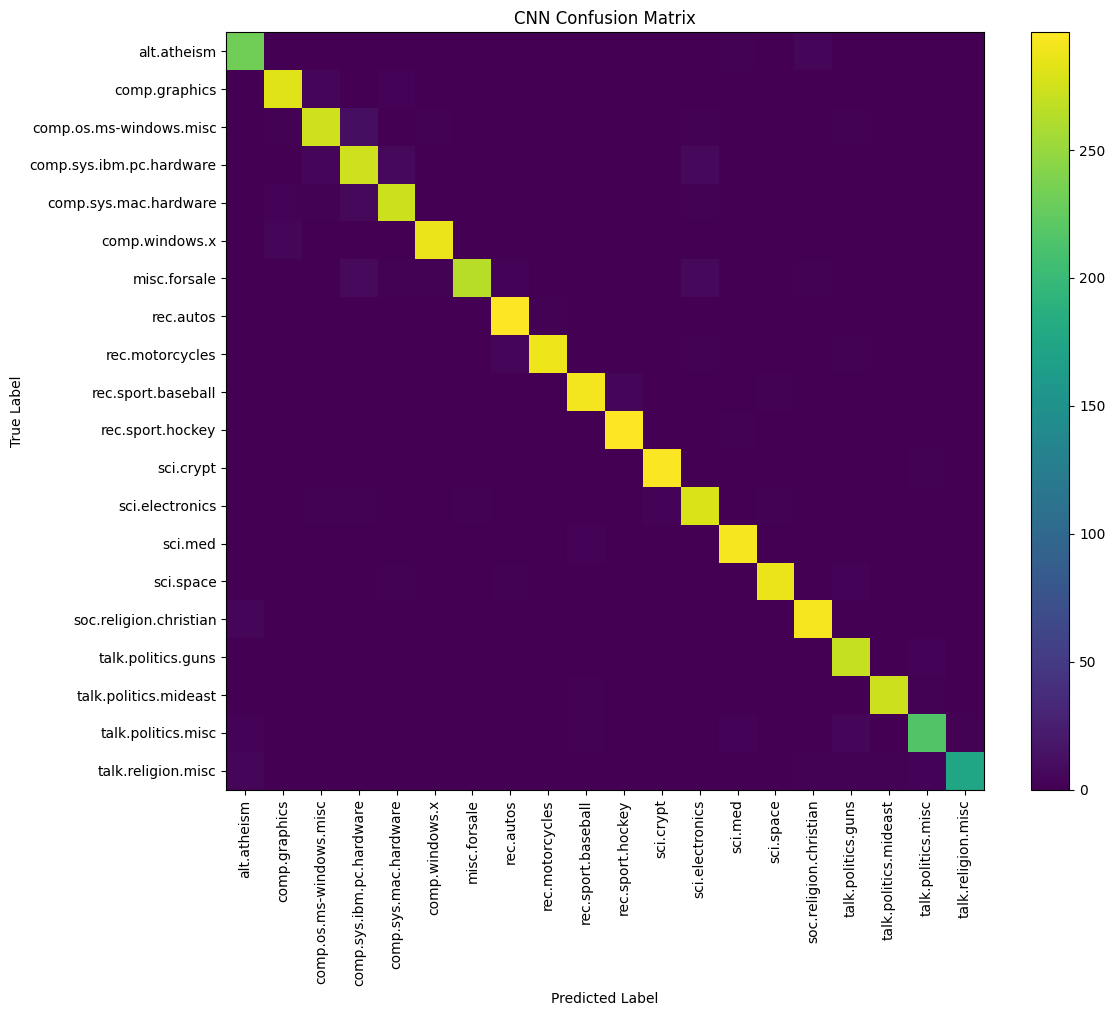

In [46]:
# Create confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(12, 10))
plt.imshow(cm)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(
    range(num_classes),
    label_encoder.classes_,
    rotation=90
)

plt.yticks(
    range(num_classes),
    label_encoder.classes_
)

plt.tight_layout()
plt.show()

# 5. RNNs

## 5.1 N-gram Feature Preparation
One important clarification before coding: for an RNN, an n-gram is normally a sequence of n consecutive tokens. Since the assignment specifically requires n=5, 10, 100, we'll use these as the sequence lengths fed to the RNN.

We already have tokenized sequences from Section 4.1, so we can reuse the tokenizer.

In [47]:
# Required n-gram sequence lengths
ngram_sizes = [5, 10, 100]

# Create padded sequences for each n-gram size
ngram_data = {}

for n in ngram_sizes:

    ngram_data[n] = {
        "train": pad_sequences(
            X_train_seq,
            maxlen=n,
            padding="post",
            truncating="post"
        ),
        
        "val": pad_sequences(
            X_val_seq,
            maxlen=n,
            padding="post",
            truncating="post"
        ),
        
        "test": pad_sequences(
            X_test_seq,
            maxlen=n,
            padding="post",
            truncating="post"
        )
    }

    print(f"n={n}")
    print("  Train:", ngram_data[n]["train"].shape)
    print("  Val  :", ngram_data[n]["val"].shape)
    print("  Test :", ngram_data[n]["test"].shape)

n=5
  Train: (26363, 5)
  Val  : (5649, 5)
  Test : (5650, 5)
n=10
  Train: (26363, 10)
  Val  : (5649, 10)
  Test : (5650, 10)
n=100
  Train: (26363, 100)
  Val  : (5649, 100)
  Test : (5650, 100)


## 5.2 Simple RNN

In [48]:
# Function to build a Simple RNN model
def build_rnn(sequence_length):

    model = Sequential([
        Input(shape=(sequence_length,)),

        Embedding(
            input_dim=vocab_size,
            output_dim=128
        ),

        SimpleRNN(128),

        Dense(128, activation="relu"),
        Dropout(0.3),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

This is a good example of why basic RNNs can struggle with long sequences. As the sequence becomes longer, the RNN has to carry information through many time steps, making it harder to preserve useful information.

## 5.3 GRU

In [50]:
# Function to build a GRU model
def build_gru(sequence_length):

    model = Sequential([
        Input(shape=(sequence_length,)),

        Embedding(
            input_dim=vocab_size,
            output_dim=128
        ),

        GRU(128),

        Dense(128, activation="relu"),
        Dropout(0.3),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 5.4 LSTM.

In [52]:
# Function to build an LSTM model
def build_lstm(sequence_length):

    model = Sequential([
        Input(shape=(sequence_length,)),

        Embedding(
            input_dim=vocab_size,
            output_dim=128
        ),

        LSTM(128),

        Dense(128, activation="relu"),
        Dropout(0.3),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 5.5 BiLSTM
A Bidirectional LSTM processes the sequence in both directions:

Forward: beginning → end
Backward: end → beginning
This allows the model to use context from both sides of a word.

In [54]:
# Function to build a Bidirectional LSTM model
def build_bilstm(sequence_length):

    model = Sequential([
        Input(shape=(sequence_length,)),

        Embedding(
            input_dim=vocab_size,
            output_dim=128
        ),

        Bidirectional(
            LSTM(128)
        ),

        Dense(128, activation="relu"),
        Dropout(0.3),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 5.6 BiGRU

In [56]:
# Function to build a Bidirectional GRU model
def build_bigru(sequence_length):

    model = Sequential([
        Input(shape=(sequence_length,)),

        Embedding(
            input_dim=vocab_size,
            output_dim=128
        ),
        Bidirectional(
            GRU(128)
        ),

        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 5.7 RNN Evaluation 

In [58]:
# 5.7 Evaluate all RNN models with n=5, 10, 100

rnn_builders = {
    "Simple RNN": build_rnn,
    "GRU": build_gru,
    "LSTM": build_lstm,
    "BiLSTM": build_bilstm,
    "BiGRU": build_bigru
}

rnn_eval_results = []
rnn_confusion_matrices = {}

for model_name, builder in rnn_builders.items():
    for n in ngram_sizes:

        print(f"Training {model_name} with n={n}...")

        # Clear previous model from memory
        tf.keras.backend.clear_session()
        # Build model
        model = builder(n)

        # Train model
        model.fit(
            ngram_data[n]["train"],
            y_train_cat,
            validation_data=(
                ngram_data[n]["val"],
                y_val_cat
            ),
            epochs=10,
            batch_size=32,
            verbose=0
        )
        # Predictions
        y_pred_probs = model.predict(
            ngram_data[n]["test"],
            verbose=0
        )
        y_pred = np.argmax(y_pred_probs, axis=1)

        # Metrics
        accuracy = accuracy_score(y_test_encoded, y_pred)
        precision = precision_score(
            y_test_encoded,
            y_pred,
            average="weighted"
        )
        recall = recall_score(
            y_test_encoded,
            y_pred,
            average="weighted"
        )
        f1 = f1_score(
            y_test_encoded,
            y_pred,
            average="weighted"
        )
        # Confusion matrix
        cm = confusion_matrix(
            y_test_encoded,
            y_pred
        )
        # Save metrics
        rnn_eval_results.append({
            "Model": model_name,
            "n": n,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        })
        # Save confusion matrix
        rnn_confusion_matrices[f"{model_name} - n={n}"] = cm
        print(
            f"Accuracy: {accuracy:.4f} | "
            f"Precision: {precision:.4f} | "
            f"Recall: {recall:.4f} | "
            f"F1: {f1:.4f}"
        )
# Convert results to DataFrame
rnn_eval_df = pd.DataFrame(rnn_eval_results)

rnn_eval_df

Training Simple RNN with n=5...
Accuracy: 0.9177 | Precision: 0.9193 | Recall: 0.9177 | F1: 0.9180
Training Simple RNN with n=10...
Accuracy: 0.9276 | Precision: 0.9294 | Recall: 0.9276 | F1: 0.9280
Training Simple RNN with n=100...
Accuracy: 0.1550 | Precision: 0.1912 | Recall: 0.1550 | F1: 0.1386
Training GRU with n=5...
Accuracy: 0.9205 | Precision: 0.9222 | Recall: 0.9205 | F1: 0.9208
Training GRU with n=10...
Accuracy: 0.9265 | Precision: 0.9281 | Recall: 0.9265 | F1: 0.9269
Training GRU with n=100...
Accuracy: 0.9542 | Precision: 0.9548 | Recall: 0.9542 | F1: 0.9542
Training LSTM with n=5...
Accuracy: 0.9205 | Precision: 0.9230 | Recall: 0.9205 | F1: 0.9209
Training LSTM with n=10...
Accuracy: 0.9359 | Precision: 0.9365 | Recall: 0.9359 | F1: 0.9360
Training LSTM with n=100...
Accuracy: 0.9480 | Precision: 0.9484 | Recall: 0.9480 | F1: 0.9480
Training BiLSTM with n=5...
Accuracy: 0.9251 | Precision: 0.9259 | Recall: 0.9251 | F1: 0.9252
Training BiLSTM with n=10...
Accuracy: 0.937

,Model,n,Accuracy,Precision,Recall,F1
0,Simple RNN,5,0.917699,0.919289,0.917699,0.917967
1,Simple RNN,10,0.927611,0.929398,0.927611,0.928003
2,Simple RNN,100,0.155044,0.191182,0.155044,0.138627
3,GRU,5,0.920531,0.922248,0.920531,0.920815
4,GRU,10,0.926549,0.928123,0.926549,0.926852
5,GRU,100,0.954159,0.954756,0.954159,0.954154
6,LSTM,5,0.920531,0.923012,0.920531,0.920944
7,LSTM,10,0.935929,0.936460,0.935929,0.935998
8,LSTM,100,0.947965,0.948378,0.947965,0.948000
9,BiLSTM,5,0.925133,0.925888,0.925133,0.925215


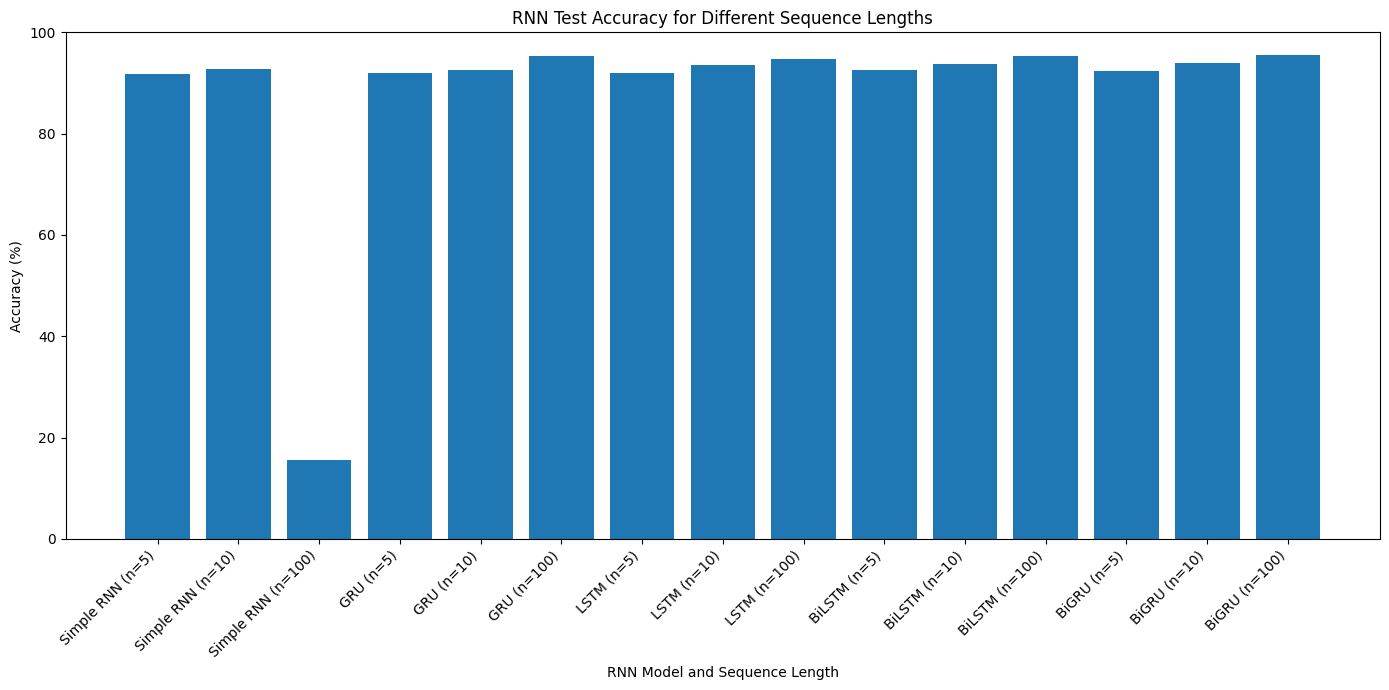

In [60]:
# Visualize RNN test results

plt.figure(figsize=(14, 7))

# Create configuration labels
rnn_eval_df["Configuration"] = (
    rnn_eval_df["Model"] +
    " (n=" +
    rnn_eval_df["n"].astype(str) +
    ")"
)

# Plot accuracy
plt.bar(
    rnn_eval_df["Configuration"],
    rnn_eval_df["Accuracy"] * 100
)

plt.xlabel("RNN Model and Sequence Length")
plt.ylabel("Accuracy (%)")
plt.title("RNN Test Accuracy for Different Sequence Lengths")

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# 6. Incorporating Pre-trained Embeddings

In [61]:
# Check required libraries

import gensim
import transformers
import torch

print("Gensim:", gensim.__version__)
print("Transformers:", transformers.__version__)
print("PyTorch:", torch.__version__)

Gensim: 4.4.0
Transformers: 5.16.1
PyTorch: 2.11.0+cu128


In [62]:
import gensim.downloader as api

print(api.info()["models"].keys())

dict_keys(['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis'])


## 6.1 Load Required Models

In [ ]:
# 6.1 Load pre-trained FastText

import gensim.downloader as api

fasttext_model = api.load("fasttext-wiki-news-subwords-300")

print("FastText loaded successfully")
print("Embedding dimension:", fasttext_model.vector_size)

1. Dataset Preparation
Load dataset
Remove headers, footers, and quotes if we decide they are unwanted metadata
EDA:
Class distribution
Document length
Basic text cleaning
Train / Validation / Test split
2. Baseline Model — ANN + TF-IDF
TF-IDF feature extraction
Try a few max_features values if needed
Prepare ANN input
ANN architecture:
Input → Dense + ReLU → Dropout → Output + Softmax
Adam optimizer
Categorical cross-entropy
Early stopping
Train and monitor epochs
3. Evaluation & Diagnostics
Accuracy
Precision
Recall
Macro F1
Weighted F1
Train/validation learning curves
Confusion matrix
Analyze which classes are confused with each other
Record baseline findings